# 👨🏻‍💻 **Team Notebook — NASA Software Defect Prediction Challenge**
## 🤖 **Machine Learning Challenge** 🤖

---

## **The Challenge**

You receive **software metrics extracted from real NASA mission code**.
Build a classifier that predicts whether a software module contains bugs.

This is a **real industry problem** — companies like NASA, Google and Microsoft
use ML to prioritise code review before releases.

---

## **Your Files**

| File                  | Description                        | Use                   |
|-----------------------|------------------------------------|-----------------------|
| `cm1.csv`             | Scientific instrument (spacecraft) | Training / Validation |
| `pc1.csv`             | Flight software (Earth satellite)  | Training / Validation |
| `jm1.csv`             | Real-time ground system (large)    | Training / Validation |
| `kc1.csv`             | Storage management system          | Training / Validation |
| `kc2_test_blind.csv`  | Secret mission — **no labels**     | Predict & Submit      |

---

## **What You Submit**

A file named **`predictions_TEAMNAME.csv`**:

```
id,defects
0,0
1,1
2,0
```

- `id` — row index (0 to 521)
- `defects` — **1 = buggy**, **0 = clean**

---

## **Scenario Details**

| Training Data             | Test Data   |
|---------------------------|-------------|
| CM1 / PC1 / JM1 / KC1     | KC2         |
| ...                       | ...         |

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

DATASETS_DIR   = "datasets/datasets"
TESTBLIND_PATH = "test-blind/test-blind/kc2_test_blind.csv"
TEAM_NAME      = "TEAMNAME"

# ── Load training sets ──────────────────────────────────────────────────────
files = ["cm1.csv", "pc1.csv", "jm1.csv", "kc1.csv"]
dfs   = []
for fname in files:
    df = pd.read_csv(f"{DATASETS_DIR}/{fname}")
    df.columns = df.columns.str.lower()          # normalise column names
    df["source"] = fname.replace(".csv", "")
    dfs.append(df)

train_raw = pd.concat(dfs, ignore_index=True)
print("Combined training shape:", train_raw.shape)
train_raw.head(3)


Combined training shape: (16920, 23)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,locomment,loblank,loccodeandcomment,uniq_op,uniq_opnd,total_op,total_opnd,branchcount,defects,source
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.3,1.30,1.30,...,2,2,2,1.2,1.2,1.2,1.2,1.4,False,cm1
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.0,1.00,1.00,...,1,1,1,1.0,1.0,1.0,1.0,1.0,True,cm1
2,24.0,5.0,1.0,3.0,63.0,309.13,0.11,9.5,32.54,2936.77,...,0,6,0,15.0,15.0,44.0,19.0,9.0,False,cm1


## 🔍 Exploratory Data Analysis

Class distribution (training):
defects
False    14365
True      2555
Name: count, dtype: int64
Imbalance ratio: 5.62:1


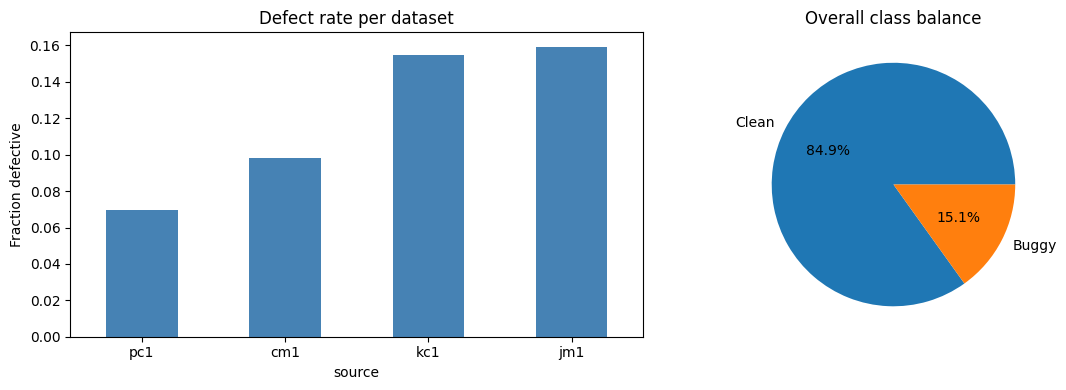


Feature statistics:


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,locode,locomment,loblank,uniq_op,uniq_opnd,total_op,total_opnd,branchcount
count,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00
mean,35.91,5.57,2.97,3.62,103.10,599.28,0.17,13.13,28.38,29834.54,0.20,1657.47,22.98,2.81,4.46,10.87,15.91,61.38,41.81,9.81
std,65.82,11.24,5.99,7.83,219.83,1681.51,0.20,17.42,31.86,358567.59,0.56,19920.42,50.91,9.51,9.98,9.19,24.53,133.15,88.66,19.74
min,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,9.00,1.00,1.00,1.00,13.00,41.51,0.04,3.00,11.36,129.72,0.01,7.21,3.00,0.00,0.00,5.00,4.00,8.00,5.00,1.00
50%,19.00,3.00,1.00,2.00,43.00,188.87,0.09,8.36,20.94,1647.46,0.06,91.53,11.00,0.00,2.00,10.00,10.00,26.00,17.00,5.00
75%,40.00,6.00,3.00,4.00,111.00,566.61,0.21,17.35,35.93,9617.60,0.19,534.31,25.00,2.00,5.00,15.00,20.00,66.00,44.00,11.00
max,3442.00,470.00,165.00,402.00,8441.00,80843.08,2.00,418.20,598.33,31079782.27,26.95,1726654.57,2824.00,344.00,447.00,411.00,1026.00,5420.00,3021.00,826.00


In [2]:
# ── Exploratory Data Analysis ───────────────────────────────────────────────
print("Class distribution (training):")
print(train_raw["defects"].value_counts())
print(f"Imbalance ratio: {train_raw['defects'].value_counts()[False]/train_raw['defects'].value_counts()[True]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-dataset defect rate
defect_rates = pd.concat([
    pd.read_csv(f"{DATASETS_DIR}/{f}").assign(source=f.replace('.csv',''))
    for f in ["cm1.csv", "pc1.csv", "jm1.csv", "kc1.csv"]
])
defect_rates.columns = defect_rates.columns.str.lower()
rates = defect_rates.groupby("source")["defects"].mean().sort_values()
rates.plot(kind="bar", ax=axes[0], color="steelblue", title="Defect rate per dataset")
axes[0].set_ylabel("Fraction defective")
axes[0].tick_params(axis="x", rotation=0)

# Overall class balance
train_raw["defects"].value_counts().plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%",
    labels=["Clean", "Buggy"], title="Overall class balance"
)
plt.tight_layout()
plt.savefig("eda_class_balance.png", dpi=100)
plt.show()

# Feature distributions (first numeric columns)
feature_cols = [c for c in train_raw.columns
                if c not in ("defects", "source", "loccodeandcomment")]
print("\nFeature statistics:")
train_raw[feature_cols].describe().round(2)


## ⚙️ Preprocessing

In [3]:
# ── Preprocessing ───────────────────────────────────────────────────────────
# Drop 'loccodeandcomment' — absent in the test set
# Drop 'source' helper column
DROP_COLS = ["loccodeandcomment", "source"]

FEATURE_COLS = [
    c for c in train_raw.columns
    if c not in DROP_COLS + ["defects"]
]

X_train = train_raw[FEATURE_COLS].copy()
y_train = train_raw["defects"].astype(int)

# ── Load test set ────────────────────────────────────────────────────────────
test_raw = pd.read_csv(TESTBLIND_PATH)
test_raw.columns = test_raw.columns.str.lower()
test_ids = test_raw["id"].values
X_test   = test_raw[FEATURE_COLS].copy()

# ── Scale features with RobustScaler (handles outliers well) ─────────────────
scaler  = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Training feature matrix:", X_train_sc.shape)
print("Test feature matrix    :", X_test_sc.shape)
print("Positive rate (train)  :", y_train.mean().round(4))

# Check for missing values
print("NaN in train:", np.isnan(X_train_sc).sum())
print("NaN in test :", np.isnan(X_test_sc).sum())


Training feature matrix: (16920, 20)
Test feature matrix    : (522, 20)
Positive rate (train)  : 0.151
NaN in train: 0
NaN in test : 0


## 🚀 XGBoost Model Training

In [4]:
# ── XGBoost — Cross-Validated Training ──────────────────────────────────────
# scale_pos_weight compensates for class imbalance
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (neg={neg}, pos={pos})")

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = cross_val_score(xgb, X_train_sc, y_train, cv=cv,
                              scoring="roc_auc", n_jobs=-1)
f1_scores  = cross_val_score(xgb, X_train_sc, y_train, cv=cv,
                              scoring="f1", n_jobs=-1)

print(f"\n5-Fold CV ROC-AUC : {roc_scores.mean():.4f} ± {roc_scores.std():.4f}")
print(f"5-Fold CV F1       : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

# ── Final model on full training data ────────────────────────────────────────
xgb.fit(X_train_sc, y_train)
print("\nModel trained on full training set.")


scale_pos_weight = 5.62  (neg=14365, pos=2555)



5-Fold CV ROC-AUC : 0.7609 ± 0.0112
5-Fold CV F1       : 0.4259 ± 0.0116



Model trained on full training set.


## 📊 Feature Importance

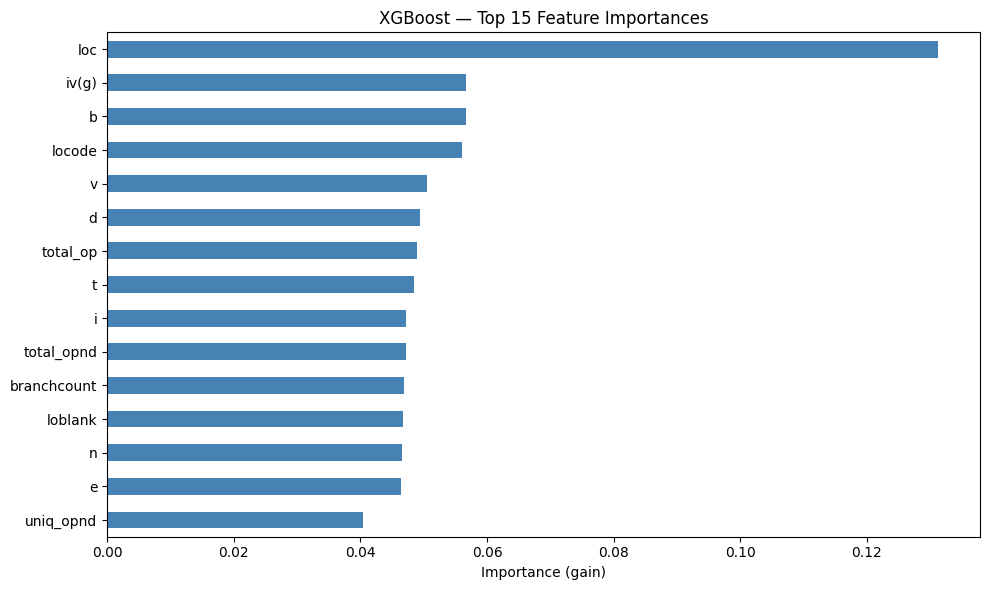

Top 10 features:
loc           0.131317
iv(g)         0.056725
b             0.056646
locode        0.055995
v             0.050451
d             0.049468
total_op      0.049004
t             0.048519
i             0.047199
total_opnd    0.047143


In [5]:
# ── Feature Importance ──────────────────────────────────────────────────────
importances = pd.Series(xgb.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_sorted.head(15).plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("XGBoost — Top 15 Feature Importances")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=100)
plt.show()

print("Top 10 features:")
print(importances_sorted.head(10).to_string())


## 🧪 Cross-Dataset Evaluation

In [6]:
# ── Per-source evaluation (leave-one-out) ───────────────────────────────────
# Useful to understand cross-dataset generalisation
results = []
source_dfs = {}
for fname in ["cm1.csv", "pc1.csv", "jm1.csv", "kc1.csv"]:
    df = pd.read_csv(f"{DATASETS_DIR}/{fname}")
    df.columns = df.columns.str.lower()
    source_dfs[fname.replace('.csv','')] = df

for held_out in source_dfs:
    # Train on the other 3
    train_src = pd.concat(
        [df for name, df in source_dfs.items() if name != held_out],
        ignore_index=True
    )
    X_s = scaler.fit_transform(train_src[FEATURE_COLS])
    y_s = train_src["defects"].astype(int)

    val_src = source_dfs[held_out]
    X_v = scaler.transform(val_src[FEATURE_COLS])
    y_v = val_src["defects"].astype(int)

    neg_s, pos_s = (y_s == 0).sum(), (y_s == 1).sum()
    clf = XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg_s/pos_s,
        eval_metric="logloss", use_label_encoder=False,
        random_state=42, n_jobs=-1
    )
    clf.fit(X_s, y_s)
    y_prob = clf.predict_proba(X_v)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    results.append({
        "held_out": held_out,
        "ROC-AUC": round(roc_auc_score(y_v, y_prob), 4),
        "F1":      round(f1_score(y_v, y_pred), 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


held_out  ROC-AUC     F1
     cm1   0.7966 0.4000
     pc1   0.7082 0.2460
     jm1   0.6010 0.2956
     kc1   0.7418 0.3266


## 📤 Generate Predictions

In [7]:
# ── Generate Predictions for kc2 ───────────────────────────────────────────
# Re-fit scaler on full training set before predicting
scaler_final = RobustScaler()
X_train_final = scaler_final.fit_transform(X_train)
X_test_final  = scaler_final.transform(X_test)

# Re-train model with full training set using final scaler
xgb_final = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)
xgb_final.fit(X_train_final, y_train)

# Predict
y_pred_test = xgb_final.predict(X_test_final)
y_prob_test = xgb_final.predict_proba(X_test_final)[:, 1]

predictions = pd.DataFrame({"id": test_ids, "defects": y_pred_test})
out_path = f"predictions_{TEAM_NAME}.csv"
predictions.to_csv(out_path, index=False)

print(f"Predictions saved to: {out_path}")
print(f"Total samples predicted: {len(predictions)}")
print(f"Predicted buggy   (1): {(y_pred_test == 1).sum()}")
print(f"Predicted clean   (0): {(y_pred_test == 0).sum()}")
print(f"Defect rate: {y_pred_test.mean():.2%}")
print()
print("First 10 predictions:")
print(predictions.head(10).to_string(index=False))


Predictions saved to: predictions_TEAMNAME.csv
Total samples predicted: 522
Predicted buggy   (1): 150
Predicted clean   (0): 372
Defect rate: 28.74%

First 10 predictions:
 id  defects
  0        0
  1        1
  2        1
  3        1
  4        1
  5        1
  6        1
  7        0
  8        0
  9        0


---
# 🔬 **V2 — Improvements & Further Experiments**
> All original cells above are preserved.  
> The cells below explore: more CV splits, feature engineering, threshold optimisation, model comparison, and an ensemble.


## 📈 V2-A — More CV Splits (10-Fold & Repeated Stratified K-Fold)

        CV strategy  Folds  ROC-AUC mean  ROC-AUC std  F1 mean  F1 std
 5-Fold  (baseline)      5        0.7609       0.0112   0.4259  0.0116
10-Fold                 10        0.7642       0.0191   0.4244  0.0236
Repeated 5×5 = 25       25        0.7635       0.0104   0.4245  0.0122


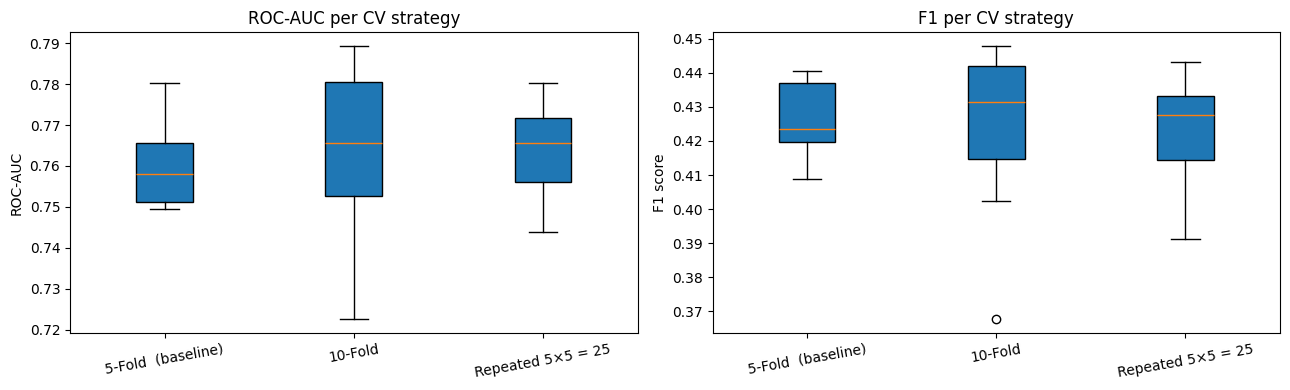

In [8]:
# ── V2-A: More CV Splits ─────────────────────────────────────────────────────
# Compare 5-fold (baseline) vs 10-fold vs Repeated Stratified K-Fold (5×5 = 25)
from sklearn.model_selection import RepeatedStratifiedKFold

xgb_v2 = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

cv_configs = {
    "5-Fold  (baseline)": StratifiedKFold(n_splits=5,  shuffle=True, random_state=42),
    "10-Fold            ": StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    "Repeated 5×5 = 25  ": RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42),
}

cv_results = []
for name, cv_obj in cv_configs.items():
    roc = cross_val_score(xgb_v2, X_train_sc, y_train, cv=cv_obj, scoring="roc_auc", n_jobs=-1)
    f1  = cross_val_score(xgb_v2, X_train_sc, y_train, cv=cv_obj, scoring="f1",      n_jobs=-1)
    cv_results.append({
        "CV strategy":    name,
        "Folds":          len(roc),
        "ROC-AUC mean":   round(roc.mean(), 4),
        "ROC-AUC std":    round(roc.std(),  4),
        "F1 mean":        round(f1.mean(),  4),
        "F1 std":         round(f1.std(),   4),
    })

cv_df = pd.DataFrame(cv_results)
print(cv_df.to_string(index=False))

# Plot CV score distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
roc_data = []
f1_data  = []
labels   = []
for name, cv_obj in cv_configs.items():
    r = cross_val_score(xgb_v2, X_train_sc, y_train, cv=cv_obj, scoring="roc_auc", n_jobs=-1)
    f = cross_val_score(xgb_v2, X_train_sc, y_train, cv=cv_obj, scoring="f1",      n_jobs=-1)
    roc_data.append(r)
    f1_data.append(f)
    labels.append(name.strip())

axes[0].boxplot(roc_data, labels=labels, patch_artist=True)
axes[0].set_title("ROC-AUC per CV strategy")
axes[0].set_ylabel("ROC-AUC")
axes[0].tick_params(axis="x", rotation=10)

axes[1].boxplot(f1_data, labels=labels, patch_artist=True)
axes[1].set_title("F1 per CV strategy")
axes[1].set_ylabel("F1 score")
axes[1].tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig("v2_cv_splits_comparison.png", dpi=100)
plt.show()


## 🛠️ V2-B — Feature Engineering (Log-Transform + Interaction Features)

In [9]:
# ── V2-B: Feature Engineering ─────────────────────────────────────────────────
# Software metrics are heavily right-skewed; log1p reduces the influence of
# extreme outliers and can improve tree-based model splits near the origin.

# Log1p-transform all features (all are non-negative metrics)
X_train_log = np.log1p(np.clip(X_train.values, 0, None))
X_test_log  = np.log1p(np.clip(X_test.values,  0, None))

# Scale the log-transformed features
scaler_log    = RobustScaler()
X_train_log_sc = scaler_log.fit_transform(X_train_log)
X_test_log_sc  = scaler_log.transform(X_test_log)

# Add two interaction features that are meaningful for software complexity:
#   ratio_ev_vg  = ev(g) / v(g)  → fraction of essential complexity
#   ratio_loc_n  = loc / n        → code density
ev_g_idx = FEATURE_COLS.index("ev(g)")
v_g_idx  = FEATURE_COLS.index("v(g)")
loc_idx  = FEATURE_COLS.index("loc")
n_idx    = FEATURE_COLS.index("n")

def add_interactions(X_sc, X_raw):
    ratio_ev_vg = (X_raw[:, ev_g_idx] + 1) / (X_raw[:, v_g_idx] + 1)
    ratio_loc_n = (X_raw[:, loc_idx]  + 1) / (X_raw[:, n_idx]   + 1)
    return np.hstack([X_sc,
                      ratio_ev_vg.reshape(-1, 1),
                      ratio_loc_n.reshape(-1, 1)])

X_train_eng = add_interactions(X_train_log_sc, X_train.values)
X_test_eng  = add_interactions(X_test_log_sc,  X_test.values)

print("Engineered feature matrix (train):", X_train_eng.shape)
print("Engineered feature matrix (test) :", X_test_eng.shape)

# Evaluate with 10-fold CV
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
xgb_eng = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", use_label_encoder=False,
    random_state=42, n_jobs=-1,
)

roc_eng = cross_val_score(xgb_eng, X_train_eng, y_train, cv=cv10, scoring="roc_auc", n_jobs=-1)
f1_eng  = cross_val_score(xgb_eng, X_train_eng, y_train, cv=cv10, scoring="f1",      n_jobs=-1)

print(f"\nWith feature engineering (10-fold CV):")
print(f"  ROC-AUC : {roc_eng.mean():.4f} ± {roc_eng.std():.4f}")
print(f"  F1      : {f1_eng.mean():.4f}  ± {f1_eng.std():.4f}")

roc_base = cross_val_score(xgb_v2, X_train_sc, y_train, cv=cv10, scoring="roc_auc", n_jobs=-1)
f1_base  = cross_val_score(xgb_v2, X_train_sc, y_train, cv=cv10, scoring="f1",      n_jobs=-1)
print(f"\nBaseline (no eng, 10-fold CV):")
print(f"  ROC-AUC : {roc_base.mean():.4f} ± {roc_base.std():.4f}")
print(f"  F1      : {f1_base.mean():.4f}  ± {f1_base.std():.4f}")


Engineered feature matrix (train): (16920, 22)
Engineered feature matrix (test) : (522, 22)



With feature engineering (10-fold CV):
  ROC-AUC : 0.7667 ± 0.0221
  F1      : 0.4308  ± 0.0276



Baseline (no eng, 10-fold CV):
  ROC-AUC : 0.7642 ± 0.0191
  F1      : 0.4244  ± 0.0236


## 🎯 V2-C — Threshold Optimisation (F1-Optimal Cut-off)

Default threshold (0.50)  → F1 = 0.4308
Optimal threshold (0.54) → F1 = 0.4323
ROC-AUC (OOF)             = 0.7666


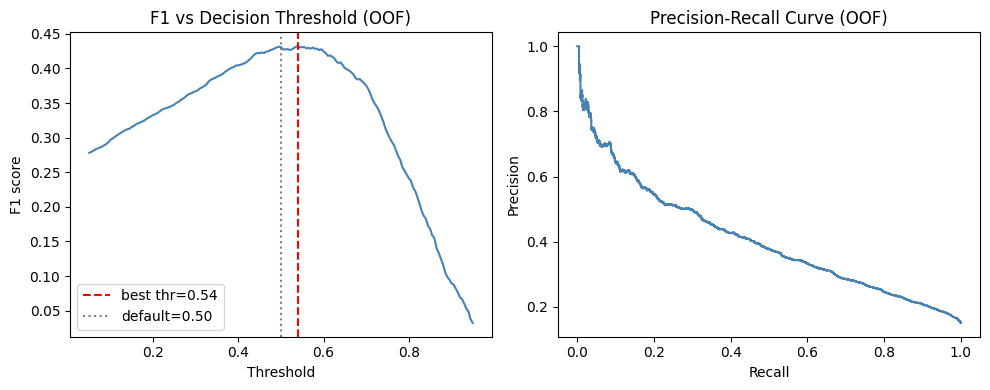

In [10]:
# ── V2-C: Threshold Optimisation ─────────────────────────────────────────────
# The default 0.5 threshold is not F1-optimal on imbalanced data.
# We find the threshold that maximises the mean out-of-fold F1.

from sklearn.metrics import precision_recall_curve

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
xgb_thr = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", use_label_encoder=False,
    random_state=42, n_jobs=-1,
)

oof_probs  = np.zeros(len(y_train))
oof_labels = np.zeros(len(y_train), dtype=int)

for train_idx, val_idx in cv10.split(X_train_eng, y_train):
    X_tr, X_val = X_train_eng[train_idx], X_train_eng[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    xgb_thr.fit(X_tr, y_tr)
    oof_probs[val_idx]  = xgb_thr.predict_proba(X_val)[:, 1]
    oof_labels[val_idx] = y_val.values

# Sweep thresholds
thresholds = np.linspace(0.05, 0.95, 181)
f1_by_thr  = [f1_score(oof_labels, (oof_probs >= t).astype(int)) for t in thresholds]
best_thr   = thresholds[np.argmax(f1_by_thr)]
best_f1    = max(f1_by_thr)

print(f"Default threshold (0.50)  → F1 = {f1_score(oof_labels, (oof_probs>=0.5).astype(int)):.4f}")
print(f"Optimal threshold ({best_thr:.2f}) → F1 = {best_f1:.4f}")
print(f"ROC-AUC (OOF)             = {roc_auc_score(oof_labels, oof_probs):.4f}")

# Plot precision-recall curve with threshold sweep
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(thresholds, f1_by_thr, color="steelblue")
plt.axvline(best_thr, color="red", linestyle="--", label=f"best thr={best_thr:.2f}")
plt.axvline(0.5,      color="grey", linestyle=":",  label="default=0.50")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("F1 vs Decision Threshold (OOF)")
plt.legend()

precision, recall, pr_thr = precision_recall_curve(oof_labels, oof_probs)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color="steelblue")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (OOF)")
plt.tight_layout()
plt.savefig("v2_threshold_opt.png", dpi=100)
plt.show()


## 🏆 V2-D — Model Comparison (XGBoost vs RandomForest vs Logistic Regression)

               Model  ROC-AUC mean  ROC-AUC std  F1 mean  F1 std
XGBoost (engineered)        0.7667       0.0221   0.4308  0.0276
       Random Forest        0.7647       0.0209   0.4225  0.0247
 Logistic Regression        0.7150       0.0146   0.3575  0.0145


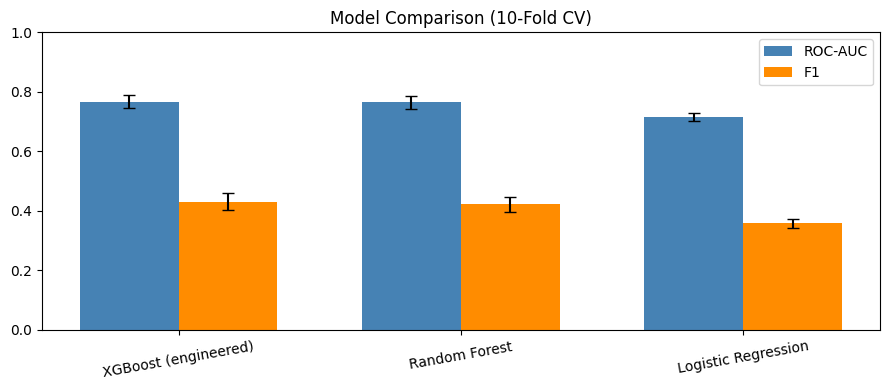

In [11]:
# ── V2-D: Model Comparison ────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "XGBoost (engineered)": XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", use_label_encoder=False,
        random_state=42, n_jobs=-1,
    ),
    "Random Forest        ": RandomForestClassifier(
        n_estimators=500, max_depth=10,
        class_weight="balanced",
        random_state=42, n_jobs=-1,
    ),
    "Logistic Regression  ": LogisticRegression(
        max_iter=1000, class_weight="balanced",
        solver="saga", random_state=42, n_jobs=-1,
    ),
}

model_results = []
for name, clf in models.items():
    X_cv = X_train_eng if "XGBoost" in name else X_train_sc
    roc = cross_val_score(clf, X_cv, y_train, cv=cv10, scoring="roc_auc", n_jobs=-1)
    f1  = cross_val_score(clf, X_cv, y_train, cv=cv10, scoring="f1",      n_jobs=-1)
    model_results.append({
        "Model":        name.strip(),
        "ROC-AUC mean": round(roc.mean(), 4),
        "ROC-AUC std":  round(roc.std(),  4),
        "F1 mean":      round(f1.mean(),  4),
        "F1 std":       round(f1.std(),   4),
    })

model_df = pd.DataFrame(model_results).sort_values("ROC-AUC mean", ascending=False)
print(model_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(model_df))
w = 0.35
ax.bar(x - w/2, model_df["ROC-AUC mean"], w, yerr=model_df["ROC-AUC std"],
       label="ROC-AUC", color="steelblue", capsize=4)
ax.bar(x + w/2, model_df["F1 mean"],      w, yerr=model_df["F1 std"],
       label="F1", color="darkorange", capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(model_df["Model"], rotation=10)
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Model Comparison (10-Fold CV)")
plt.tight_layout()
plt.savefig("v2_model_comparison.png", dpi=100)
plt.show()


## 🤝 V2-E — Soft-Voting Ensemble

In [12]:
# ── V2-E: Soft-Voting Ensemble ────────────────────────────────────────────────
# Combine XGBoost + RandomForest probabilities for a more robust prediction.
# Use a Pipeline wrapper so RandomForest also benefits from the engineered features.

from sklearn.pipeline import FunctionTransformer, Pipeline
from sklearn.ensemble import VotingClassifier

# Both models get the same engineered features
xgb_ens = XGBClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss", use_label_encoder=False,
    random_state=42, n_jobs=-1,
)
rf_ens = RandomForestClassifier(
    n_estimators=500, max_depth=10,
    class_weight="balanced",
    random_state=42, n_jobs=-1,
)

ensemble = VotingClassifier(
    estimators=[("xgb", xgb_ens), ("rf", rf_ens)],
    voting="soft",
    n_jobs=-1,
)

cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
roc_ens = cross_val_score(ensemble, X_train_eng, y_train, cv=cv10, scoring="roc_auc", n_jobs=-1)
f1_ens  = cross_val_score(ensemble, X_train_eng, y_train, cv=cv10, scoring="f1",      n_jobs=-1)

print(f"Soft-Voting Ensemble (10-fold CV):")
print(f"  ROC-AUC : {roc_ens.mean():.4f} ± {roc_ens.std():.4f}")
print(f"  F1      : {f1_ens.mean():.4f}  ± {f1_ens.std():.4f}")

# Compare against standalone XGBoost (engineered)
print(f"\nXGBoost-only baseline (10-fold CV):")
print(f"  ROC-AUC : {roc_eng.mean():.4f} ± {roc_eng.std():.4f}")
print(f"  F1      : {f1_eng.mean():.4f}  ± {f1_eng.std():.4f}")


[09:50:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:50:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:50:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:50:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



[09:50:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:50:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:50:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:50:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



[09:51:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:51:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



[09:51:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:51:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:51:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:51:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



[09:51:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:51:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:51:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:51:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



[09:51:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[09:51:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Soft-Voting Ensemble (10-fold CV):
  ROC-AUC : 0.7714 ± 0.0222
  F1      : 0.4339  ± 0.0283

XGBoost-only baseline (10-fold CV):
  ROC-AUC : 0.7667 ± 0.0221
  F1      : 0.4308  ± 0.0276


## 📤 V2-F — Improved Predictions (Ensemble + Optimal Threshold)

In [13]:
# ── V2-F: Improved Predictions ───────────────────────────────────────────────
# Final model: soft-voting ensemble trained on all data,
# with F1-optimal threshold found in V2-C.

ensemble_final = VotingClassifier(
    estimators=[
        ("xgb", XGBClassifier(
            n_estimators=500, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss", use_label_encoder=False,
            random_state=42, n_jobs=-1,
        )),
        ("rf", RandomForestClassifier(
            n_estimators=500, max_depth=10,
            class_weight="balanced",
            random_state=42, n_jobs=-1,
        )),
    ],
    voting="soft",
    n_jobs=-1,
)
ensemble_final.fit(X_train_eng, y_train)

y_prob_v2  = ensemble_final.predict_proba(X_test_eng)[:, 1]
y_pred_v2  = (y_prob_v2 >= best_thr).astype(int)

predictions_v2 = pd.DataFrame({"id": test_ids, "defects": y_pred_v2})
out_path_v2    = f"predictions_{TEAM_NAME}_v2.csv"
predictions_v2.to_csv(out_path_v2, index=False)

print(f"V2 Predictions saved to : {out_path_v2}")
print(f"Threshold used          : {best_thr:.2f}  (F1-optimal from V2-C)")
print(f"Total samples           : {len(predictions_v2)}")
print(f"Predicted buggy   (1)   : {(y_pred_v2 == 1).sum()}")
print(f"Predicted clean   (0)   : {(y_pred_v2 == 0).sum()}")
print(f"Defect rate             : {y_pred_v2.mean():.2%}")
print()

# Side-by-side comparison with V1 predictions
v1_preds = pd.read_csv(f"predictions_{TEAM_NAME}.csv")
agree    = (v1_preds["defects"].values == predictions_v2["defects"].values).sum()
print(f"V1 vs V2 agreement      : {agree}/{len(v1_preds)} ({agree/len(v1_preds):.1%})")
print()
print("First 10 V2 predictions:")
print(predictions_v2.head(10).to_string(index=False))


V2 Predictions saved to : predictions_TEAMNAME_v2.csv
Threshold used          : 0.54  (F1-optimal from V2-C)
Total samples           : 522
Predicted buggy   (1)   : 124
Predicted clean   (0)   : 398
Defect rate             : 23.75%

V1 vs V2 agreement      : 480/522 (92.0%)

First 10 V2 predictions:
 id  defects
  0        0
  1        1
  2        1
  3        1
  4        1
  5        1
  6        1
  7        0
  8        0
  9        0
